# Abbiategrasso: popolazione e consumo di suolo

Notebook locale unico per una prima lettura di Abbiategrasso.

Obiettivo:
- fissare una fotografia minima del comune
- aggiungere un confronto leggero con alcuni comuni vicini o comparabili


## Export figure

Le figure di questa repo nascono nei notebook e vengono esportate in `figures/`.
Il notebook resta eseguito e leggibile su GitHub, ma il PNG esportato e' il riferimento stabile per README e note.


In [1]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd


def find_workspace_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'dataset-incubator').exists() and (candidate / 'abbiategrasso-data-notes').exists():
            return candidate
    raise FileNotFoundError('Workspace root non trovato')


repo_root = next((p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / 'README.md').exists() and p.name == 'abbiategrasso-data-notes'), None)
if repo_root is None:
    raise FileNotFoundError('Repo root non trovata')

bundled_csv = repo_root / 'data' / 'abbiategrasso_benchmark_min.csv'
figures_dir = repo_root / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

def save_figure(fig, filename: str) -> Path:
    out = figures_dir / filename
    fig.tight_layout()
    fig.savefig(out, dpi=180, bbox_inches='tight')
    return out


workspace = None
dataset_incubator = None
pop_path = None
suolo_path = None
if not bundled_csv.exists():
    workspace = find_workspace_root(Path.cwd().resolve())
    dataset_incubator = workspace / 'dataset-incubator'
    pop_path = dataset_incubator / 'out' / 'data' / 'mart' / 'popolazione_istat_comunale_2019_2025' / '2025' / 'popolazione_by_comune.parquet'
    suolo_path = dataset_incubator / 'out' / 'data' / 'mart' / 'ispra_consumo_suolo' / '2024' / 'mart_comuni.parquet'

con = duckdb.connect()
bundled_csv


WindowsPath('C:/Users/gabry/OneDrive/Desktop/dataciviclab-workspace/abbiategrasso-data-notes/data/abbiategrasso_benchmark_min.csv')

## 1. Snapshot del comune

Partiamo da una fotografia minima di Abbiategrasso, incrociando popolazione residente e consumo di suolo.


In [2]:
if bundled_csv.exists():
    bundled_df = pd.read_csv(bundled_csv, dtype={'codice_comune': str})
    snapshot = bundled_df[bundled_df['comune'].str.lower() == 'abbiategrasso'].copy()
    snapshot = snapshot.rename(columns={'mq_suolo_per_residente': 'mq_suolo_consumato_per_residente'})
else:
    snapshot_query = '''
with pop as (
    select codice_comune, comune, popolazione_residente
    from read_parquet(?)
    where lower(comune) = 'abbiategrasso'
),
suolo as (
    select lpad(pro_com, 6, '0') as codice_comune, comune, stock_ha_2024, stock_pct_2024, incremento_ha_2023_2024
    from read_parquet(?)
    where lower(comune) = 'abbiategrasso'
)
select
    pop.codice_comune,
    pop.comune,
    popolazione_residente,
    stock_ha_2024,
    stock_pct_2024,
    incremento_ha_2023_2024,
    round(stock_ha_2024 * 10000.0 / popolazione_residente, 2) as mq_suolo_consumato_per_residente,
    round(incremento_ha_2023_2024 * 10000.0 / popolazione_residente, 2) as mq_incremento_per_residente
from pop
join suolo using (codice_comune)
'''
    snapshot = con.execute(snapshot_query, [pop_path.as_posix(), suolo_path.as_posix()]).df()

snapshot


,codice_comune,comune,popolazione_residente,stock_ha_2024,stock_pct_2024,incremento_ha_2023_2024,mq_suolo_consumato_per_residente,mq_incremento_per_residente
0,015002,Abbiategrasso,32658,710.4,14.8806,8.84,217.53,2.71


Lettura minima:

- popolazione residente 2025: circa 32,7 mila abitanti
- stock di suolo consumato 2024: oltre 710 ettari
- incremento recente: quasi 9 ettari nel solo 2023-2024
- tradotto per residente, il segnale recente vale circa 2,7 mq per abitante


## 2. Confronto con comuni vicini

Aggiungiamo un benchmark leggero con alcuni comuni vicini o comparabili, senza pretesa di matching rigoroso.


In [3]:
comuni = ['Abbiategrasso', 'Magenta', 'Vigevano', 'Buccinasco', 'Rozzano', 'Corsico']

if bundled_csv.exists():
    benchmark = pd.read_csv(bundled_csv, dtype={'codice_comune': str})
    benchmark = benchmark.sort_values('mq_suolo_per_residente', ascending=False).reset_index(drop=True)
else:
    names = ','.join([f"'{c}'" for c in comuni])
    benchmark_query = f'''
with pop as (
  select codice_comune, comune, popolazione_residente
  from read_parquet(?)
  where comune in ({names})
),
suolo as (
  select lpad(pro_com, 6, '0') as codice_comune, comune, stock_ha_2024, stock_pct_2024, incremento_ha_2023_2024
  from read_parquet(?)
  where comune in ({names})
)
select
  pop.comune,
  popolazione_residente,
  stock_ha_2024,
  stock_pct_2024,
  incremento_ha_2023_2024,
  round(stock_ha_2024 * 10000.0 / popolazione_residente, 2) as mq_suolo_per_residente,
  round(incremento_ha_2023_2024 * 10000.0 / popolazione_residente, 2) as mq_incremento_per_residente
from pop
join suolo using (codice_comune)
order by mq_suolo_per_residente desc
'''
    benchmark = con.execute(benchmark_query, [pop_path.as_posix(), suolo_path.as_posix()]).df()

benchmark


,codice_comune,comune,popolazione_residente,stock_ha_2024,stock_pct_2024,incremento_ha_2023_2024,mq_suolo_per_residente,mq_incremento_per_residente
0,015130,Magenta,24752,577.13,26.2639,1.20,233.16,0.48
1,018177,Vigevano,62771,1429.87,17.5866,2.25,227.79,0.36
2,015002,Abbiategrasso,32658,710.40,14.8806,8.84,217.53,2.71
3,015036,Buccinasco,26432,372.14,31.0243,0.14,140.79,0.05
4,015189,Rozzano,41559,510.03,41.7008,2.89,122.72,0.70
5,015093,Corsico,34694,352.52,65.7515,-0.19,101.61,-0.05


Lettura minima del benchmark:

- Magenta e Vigevano stanno sopra Abbiategrasso per `mq di suolo consumato per residente`
- Abbiategrasso resta comunque nella fascia alta del set scelto
- sul segnale di incremento recente per residente, Abbiategrasso emerge piu' chiaramente degli altri comuni inclusi


WindowsPath('C:/Users/gabry/OneDrive/Desktop/dataciviclab-workspace/abbiategrasso-data-notes/figures/abbiategrasso_vs_comuni_suolo_per_residente.png')

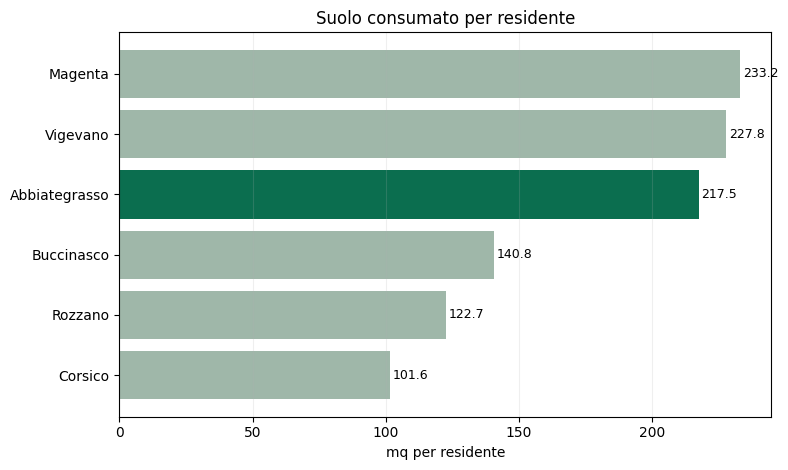

In [4]:
plot_df = benchmark.sort_values('mq_suolo_per_residente', ascending=True)
colors = ['#0b6e4f' if comune == 'Abbiategrasso' else '#9fb7a9' for comune in plot_df['comune']]

fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.barh(plot_df['comune'], plot_df['mq_suolo_per_residente'], color=colors)
ax.set_title('Suolo consumato per residente')
ax.set_xlabel('mq per residente')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.2)
for bar, value in zip(bars, plot_df['mq_suolo_per_residente']):
    ax.text(value + 1, bar.get_y() + bar.get_height() / 2, f'{value:.1f}', va='center', fontsize=9)
fig_path = save_figure(fig, 'abbiategrasso_vs_comuni_suolo_per_residente.png')
fig_path


## 3. Prossimo passo

Se questo formato regge, il passo successivo sensato e' aggiungere un secondo indicatore locale comparativo:

- incremento recente per residente
- oppure un benchmark piu' stretto sul Sud Ovest milanese
